# IIDS67692: ASSIGNMENT PART A

## Imports
Load all required libraries

In [1]:
import os,csv,re
import pandas as pd
import numpy as np
import scanpy as sc
import math
import SpaGCN as spg
from scipy.sparse import issparse
import random, torch
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import SpaGCN as spg
import cv2
import random, torch
from sklearn import metrics

*SpaGCN*- It is a graph convolutional neural network to integrate gene expression, spatial coordinates and histology image features. It uses early fusion 

## Load the Data

In [2]:
#Read in gene expression and spatial location
adata_spg = sc.read_visium(path = '/space_mounts/large_files/Assignment/151676', 
                       count_file='filtered_feature_bc_matrix.h5',                    
                       load_images=True)
adata_spg.var_names_make_unique()
adata_spg.var['SYMBOL'] = adata_spg.var_names

# Ground-truth labels
histo_2 = pd.read_csv('/space_mounts/large_files/Assignment/151676/151676_truth.txt',sep="\t").dropna()
histo_2.index = histo_2['Barcode']
adata_spg = adata_spg[adata_spg.obs_names.isin(histo_2['Barcode']),:]

# Spatial
spatial=pd.read_csv("/space_mounts/large_files/Assignment/151676/spatial/tissue_positions_list.csv",sep=",",header=None,na_filter=False,index_col=0)

# Image
img=cv2.imread("/space_mounts/large_files/Assignment/151676/spatial/151676_full_image.tif")

[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 40961 (0xa001) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65325 (0xff2d) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65326 (0xff2e) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65327 (0xff2f) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65329 (0xff31) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65330 (0xff32) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65331 (0xff33) encountered
[ WARN:0@7.954] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 65332 (0xff34) encountered
[ WARN:0

In [3]:
# Quick data exploration to verify everything
print(adata_spg)

print("\nShape:")
print(adata_spg.shape)

print("\nGround truth labels:")
print(histo_2['Annotations'].value_counts())

print("\nNumber of unique labels:")
print(histo_2['Annotations'].nunique())

print("\nSpatial coordinates:")
print(spatial.head())

print("\nImage shape:")
print(img.shape)

View of AnnData object with n_obs × n_vars = 3431 × 33538
    obs: 'in_tissue', 'array_row', 'array_col'
    var: 'gene_ids', 'feature_types', 'genome', 'SYMBOL'
    uns: 'spatial'
    obsm: 'spatial'

Shape:
(3431, 33538)

Ground truth labels:
Annotations
Layer_3    836
Layer_5    649
Layer_6    616
WM         533
Layer_1    289
Layer_2    254
Layer_4    254
Name: count, dtype: int64

Number of unique labels:
7

Spatial coordinates:
                    1  2  3     4     5
0                                      
ACGCCTGACACGCGCT-1  0  0  0  2624  2673
TACCGATCCAACACTT-1  0  1  1  2745  2741
ATTAAAGCGGACGAGC-1  0  0  2  2625  2810
GATAAGGGACGATTAG-1  0  1  3  2746  2878
GTGCAAATCACCAATA-1  0  0  4  2626  2948

Image shape:
(13332, 13332, 3)


In [4]:
#map spatial csv columns to adata.obs for easy access
adata_spg.obs["x1"]=spatial[1] #in_tissue
adata_spg.obs["x2"]=spatial[2] #array_row
adata_spg.obs["x3"]=spatial[3] #array_col
adata_spg.obs["x4"]=spatial[4] #pixel_row
adata_spg.obs["x5"]=spatial[5] #pixel_col

#Create descriptive names
adata_spg.obs["x_array"]=adata_spg.obs["x2"] 
adata_spg.obs["y_array"]=adata_spg.obs["x3"]
adata_spg.obs["x_pixel"]=adata_spg.obs["x4"]
adata_spg.obs["y_pixel"]=adata_spg.obs["x5"]


#Select captured samples
adata_spg=adata_spg[adata_spg.obs["x1"]==1] #spots captured on tissues

#uppercase gene names
adata_spg.var_names=[i.upper() for i in list(adata_spg.var_names)]
adata_spg.var["genename"]=adata_spg.var.index.astype("str")

adata_spg.write_h5ad("sample_data.h5ad")
adata_spg=sc.read("sample_data.h5ad")

#Set coordinates
x_array=adata_spg.obs["x_array"].tolist()
y_array=adata_spg.obs["y_array"].tolist()
x_pixel=adata_spg.obs["x_pixel"].tolist()
y_pixel=adata_spg.obs["y_pixel"].tolist()

#Test coordinates on the image
img_new=img.copy()
for i in range(len(x_pixel)):
    x=x_pixel[i]
    y=y_pixel[i]
    img_new[int(x-20):int(x+20), int(y-20):int(y+20),:]=0


cv2.imwrite('ic_map.jpg', img_new)

True

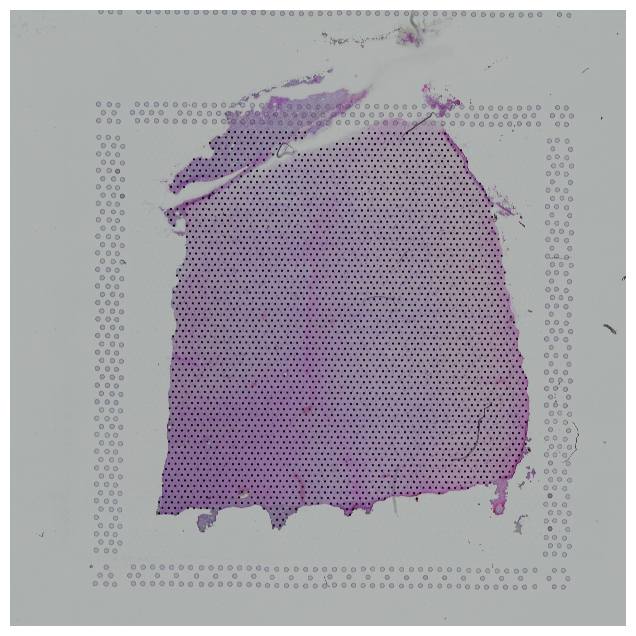

In [5]:
#plot the verified image
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img_new, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

## Preprocess the data
preprocessing is only done once on the raw data. Cleaned object is saved as adata_preprocessed and this will be restored at the start of every diffent alpha run(s=0,1,10).

In [6]:
spg.prefilter_genes(adata_spg,min_cells=3) # avoiding all genes are zeros
spg.prefilter_specialgenes(adata_spg)
#Normalize and take log for UMI
sc.pp.normalize_per_cell(adata_spg)
sc.pp.log1p(adata_spg)
adata_preprocessed = adata_spg.copy()

In [7]:
print("genes retained",adata_spg.n_vars)

genes retained 18640


In [8]:
#global random seeds
r_seed = 100
n_seed = 100
t_seed = 100

## SpaGCN with s=1

In [9]:
adata_spg = adata_preprocessed.copy()

#Calculate adjacent matrix
s=1 #alpha: relative weight of image channel in the adjacency matrix
b=49 #beta
#calculate the weighted adjacency matrix
adj=spg.calculate_adj_matrix(x=x_pixel,y=y_pixel, x_pixel=x_pixel, y_pixel=y_pixel, image=img, beta=b, alpha=s, histology=True)

np.savetxt('ic_adj.csv', adj, delimiter=',')

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  29.477509465304824 174.8015556779522 60.95093839727311
Var of x,y,z =  5080995.703721643 4365111.426668278 5080995.703721643


In [10]:
adj=np.loadtxt('ic_adj.csv', delimiter=',')
p=0.5 
#Find the l value given p (l determines the graph bandwidth)
l=spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)

Run 1: l [0.01, 1000], p [0.0, 161.7471317017666]
Run 2: l [0.01, 500.005], p [0.0, 30.984823179124525]
Run 3: l [0.01, 250.0075], p [0.0, 4.849617891160691]
Run 4: l [0.01, 125.00874999999999], p [0.0, 0.6140842850865946]
Run 5: l [62.509375, 125.00874999999999], p [0.03502943121229607, 0.6140842850865946]
Run 6: l [93.7590625, 125.00874999999999], p [0.22746464452421056, 0.6140842850865946]
Run 7: l [109.38390625, 125.00874999999999], p [0.39411875367635885, 0.6140842850865946]
recommended l =  117.196328125


## Train SpaGCN and cluster with k-means (n_clusters=7)

In [11]:
clf=spg.SpaGCN()
clf.set_l(l) #pass l value to the model

#Set seed
random.seed(r_seed)
torch.manual_seed(t_seed)
np.random.seed(n_seed)

#Run
clf.train(adata_spg,adj,init_spa=True,init="kmeans",n_clusters=7, tol=5e-3, lr=0.05, max_epochs=200)
y_pred, prob=clf.predict()

adata_spg.obs["pred"]= y_pred
adata_spg.obs["pred"]=adata_spg.obs["pred"].astype('category')

#Do cluster refinement(optional)
#shape="hexagon" for Visium data, "square" for ST data.
adj_2d=spg.calculate_adj_matrix(x=x_array,y=y_array, histology=False)

#this smooths cluster boundries
refined_pred=spg.refine(sample_id=adata_spg.obs.index.tolist(), pred=adata_spg.obs["pred"].tolist(), dis=adj_2d, shape="hexagon")

#final refined predictions
adata_spg.obs["SpaGCN_clusters"]=refined_pred
adata_spg.obs["SpaGCN_clusters"]=adata_spg.obs["SpaGCN_clusters"].astype('category')

Initializing cluster centers with kmeans, n_clusters known
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
Epoch  50
Epoch  60
Epoch  70
Epoch  80
Epoch  90
Epoch  100
Epoch  110
Epoch  120
Epoch  130
Epoch  140
Epoch  150
Epoch  160
Epoch  170
Epoch  180
Epoch  190
Calculateing adj matrix using xy only...


In [12]:
print(adata_spg.obs["SpaGCN_clusters"].value_counts())
print(adata_spg.obs["SpaGCN_clusters"].nunique())

SpaGCN_clusters
1    764
2    644
3    536
6    534
5    324
0    316
4    313
Name: count, dtype: int64
7


In [13]:
adata_spg.obs['ground_truth']=histo_2['Annotations']

## Visualise Cluster Spatially

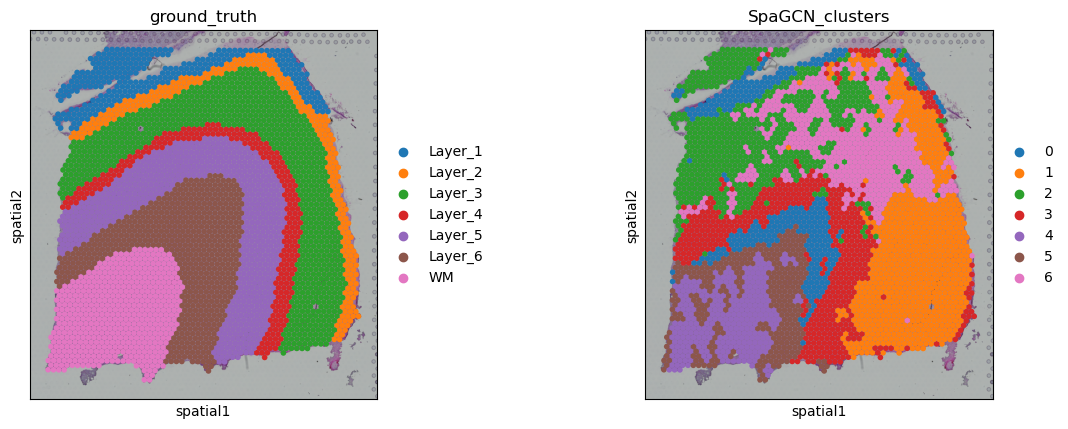

In [14]:
# plot ground-truth left and predicted cluster labels on the right
sc.pl.spatial(adata_spg,color=['ground_truth','SpaGCN_clusters'],size=1.5)

## Evaluate cluster performance

In [15]:
mut_info_1=metrics.fowlkes_mallows_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
adj_rand_1=metrics.adjusted_rand_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
adj_mut_info_1=metrics.adjusted_mutual_info_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
print(f"FMI  (Fowlkes-Mallows Index)       = {mut_info_1:.4f}")
print(f"ARI  (Adjusted Rand Index)         = {adj_rand_1:.4f}")
print(f"AMI  (Adjusted Mutual Information) = {adj_mut_info_1:.4f}")

FMI  (Fowlkes-Mallows Index)       = 0.3594
ARI  (Adjusted Rand Index)         = 0.2335
AMI  (Adjusted Mutual Information) = 0.3940


## Per layer recovery accuracy

In [20]:
ct=pd.crosstab(
    adata_spg.obs["ground_truth"],
    adata_spg.obs["SpaGCN_clusters"]
)
ct

SpaGCN_clusters,0,1,2,3,4,5,6
ground_truth,,,,,,,
Layer_1,119,9,131,24,0,0,6
Layer_2,9,109,50,32,0,0,54
Layer_3,1,358,265,5,0,0,207
Layer_4,2,111,62,10,0,0,69
Layer_5,0,174,127,168,0,0,180
Layer_6,185,3,9,297,7,97,18
WM,0,0,0,0,306,227,0


In [21]:
# Per-layer recovery
layer_recovery = pd.DataFrame(index=ct.index)

layer_recovery['Total_spots'] = ct.sum(axis=1)
layer_recovery['Best_matching_cluster'] = ct.idxmax(axis=1)
layer_recovery['Correctly_grouped_spots'] = ct.max(axis=1)

layer_recovery['Recovery_%'] = (
    100 * layer_recovery['Correctly_grouped_spots']
    / layer_recovery['Total_spots']
)

print(layer_recovery.round(2))
recovery_s1 = layer_recovery['Recovery_%']

              Total_spots  Best_matching_cluster  Correctly_grouped_spots  \
ground_truth                                                                
Layer_1               289                      2                      131   
Layer_2               254                      1                      109   
Layer_3               836                      1                      358   
Layer_4               254                      1                      111   
Layer_5               649                      6                      180   
Layer_6               616                      3                      297   
WM                    533                      4                      306   

              Recovery_%  
ground_truth              
Layer_1            45.33  
Layer_2            42.91  
Layer_3            42.82  
Layer_4            43.70  
Layer_5            27.73  
Layer_6            48.21  
WM                 57.41  


## SpaGCN with s=0

In [22]:
adata_spg = adata_preprocessed.copy()
#Calculate adjacent matrix
s=0
adj=spg.calculate_adj_matrix(x=x_pixel,y=y_pixel, histology=False)

np.savetxt('ic_adj.csv', adj, delimiter=',')

Calculateing adj matrix using xy only...


In [23]:
adj = np.loadtxt('ic_adj.csv', delimiter=',')
p=0.5 
#Find the l value given p
l=spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)

Run 1: l [0.01, 1000], p [0.0, 302.62071458079413]
Run 2: l [0.01, 500.005], p [0.0, 83.80004894257544]
Run 3: l [0.01, 250.0075], p [0.0, 21.37005506118509]
Run 4: l [0.01, 125.00874999999999], p [0.0, 4.762879245202213]
Run 5: l [0.01, 62.509375], p [0.0, 0.5128654392034084]
Run 6: l [31.2596875, 62.509375], p [0.0003415576394873998, 0.5128654392034084]
Run 7: l [46.884531249999995, 62.509375], p [0.07649905731197992, 0.5128654392034084]
Run 8: l [54.69695312499999, 62.509375], p [0.24173282313887645, 0.5128654392034084]
Run 9: l [58.6031640625, 62.509375], p [0.3651380175803276, 0.5128654392034084]
Run 10: l [60.556269531249995, 62.509375], p [0.43615876613655646, 0.5128654392034084]
Run 11: l [61.532822265625, 62.509375], p [0.4738272117141782, 0.5128654392034084]
recommended l =  62.021098632812496


In [24]:
clf=spg.SpaGCN()
clf.set_l(l)

#Set seed
random.seed(r_seed)
torch.manual_seed(t_seed)
np.random.seed(n_seed)

#Run
clf.train(adata_spg,adj,init_spa=True,init="kmeans",n_clusters=7, tol=5e-3, lr=0.05, max_epochs=200)

y_pred, prob=clf.predict()
adata_spg.obs["pred"]= y_pred
adata_spg.obs["pred"]=adata_spg.obs["pred"].astype('category')

#Do cluster refinement(optional)
#shape="hexagon" for Visium data, "square" for ST data.
adj_2d=spg.calculate_adj_matrix(x=x_array,y=y_array, histology=False)
refined_pred=spg.refine(sample_id=adata_spg.obs.index.tolist(), pred=adata_spg.obs["pred"].tolist(), dis=adj_2d, shape="hexagon")

#final refined cluster labels
adata_spg.obs["SpaGCN_clusters"]=refined_pred
adata_spg.obs["SpaGCN_clusters"]=adata_spg.obs["SpaGCN_clusters"].astype('category')

Initializing cluster centers with kmeans, n_clusters known
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
delta_label  0.004954823666569514 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 40
Calculateing adj matrix using xy only...


In [25]:
adata_spg.obs['ground_truth']=histo_2['Annotations']

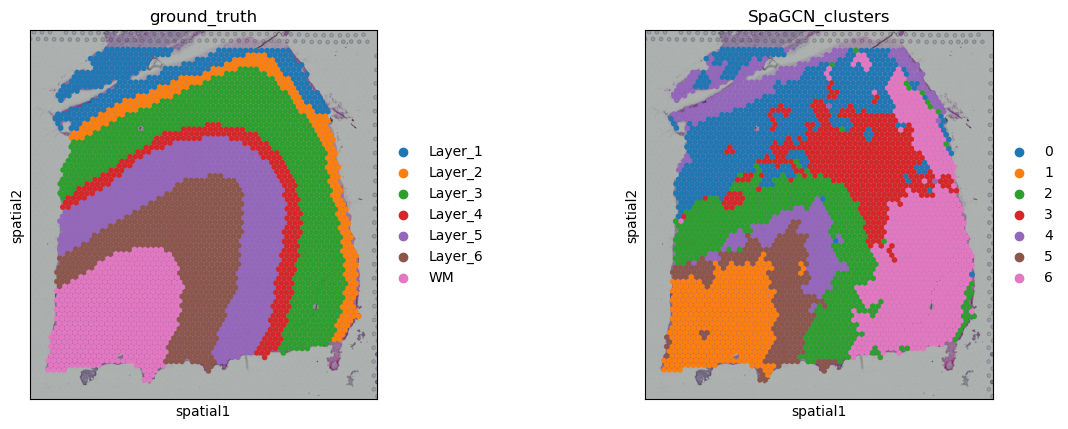

In [26]:
# plot ground-truth left and predicted cluster labels on the right
sc.pl.spatial(adata_spg,color=['ground_truth','SpaGCN_clusters'],size=1.5)

In [27]:
mut_info_0=metrics.fowlkes_mallows_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
adj_rand_0=metrics.adjusted_rand_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
adj_mut_info_0=metrics.adjusted_mutual_info_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
print(f"FMI  (Fowlkes-Mallows Index)       = {mut_info_0:.4f}")
print(f"ARI  (Adjusted Rand Index)         = {adj_rand_0:.4f}")
print(f"AMI  (Adjusted Mutual Information) = {adj_mut_info_0:.4f}")

FMI  (Fowlkes-Mallows Index)       = 0.4063
ARI  (Adjusted Rand Index)         = 0.2912
AMI  (Adjusted Mutual Information) = 0.4524


In [28]:
ct=pd.crosstab(
    adata_spg.obs["ground_truth"],
    adata_spg.obs["SpaGCN_clusters"]
)
ct

SpaGCN_clusters,0,1,2,3,4,5,6
ground_truth,,,,,,,
Layer_1,95,0,6,0,181,0,7
Layer_2,100,0,20,6,15,0,113
Layer_3,327,0,2,142,7,0,358
Layer_4,70,0,5,69,0,0,110
Layer_5,51,0,235,240,0,1,122
Layer_6,2,8,289,14,166,137,0
WM,0,395,0,0,0,138,0


In [29]:
# Per-layer recovery
layer_recovery = pd.DataFrame(index=ct.index)

layer_recovery['Total_spots'] = ct.sum(axis=1)
layer_recovery['Best_matching_cluster'] = ct.idxmax(axis=1)
layer_recovery['Correctly_grouped_spots'] = ct.max(axis=1)

layer_recovery['Recovery_%'] = (
    100 * layer_recovery['Correctly_grouped_spots']
    / layer_recovery['Total_spots']
)

print(layer_recovery.round(2))
recovery_s0 = layer_recovery['Recovery_%']

              Total_spots  Best_matching_cluster  Correctly_grouped_spots  \
ground_truth                                                                
Layer_1               289                      4                      181   
Layer_2               254                      6                      113   
Layer_3               836                      6                      358   
Layer_4               254                      6                      110   
Layer_5               649                      3                      240   
Layer_6               616                      2                      289   
WM                    533                      1                      395   

              Recovery_%  
ground_truth              
Layer_1            62.63  
Layer_2            44.49  
Layer_3            42.82  
Layer_4            43.31  
Layer_5            36.98  
Layer_6            46.92  
WM                 74.11  


## SpaGCN with s=10

In [30]:
adata_spg = adata_preprocessed.copy()
#Calculate adjacent matrix
s=10
b=49
adj=spg.calculate_adj_matrix(x=x_pixel,y=y_pixel, x_pixel=x_pixel, y_pixel=y_pixel, image=img, beta=b, alpha=s, histology=True)

np.savetxt('ic_adj.csv', adj, delimiter=',')

Calculateing adj matrix using histology image...
Var of c0,c1,c2 =  29.477509465304824 174.8015556779522 60.95093839727311
Var of x,y,z =  5080995.703721643 4365111.426668278 508099570.37216437


In [31]:
adj = np.loadtxt('ic_adj.csv', delimiter=',')
p=0.5 
#Find the l value given p
l=spg.search_l(p, adj, start=0.01, end=1000, tol=0.01, max_run=100)

Run 1: l [0.01, 1000], p [0.0, 20.07133849349175]
Run 2: l [0.01, 500.005], p [0.0, 3.4055986566181993]
recommended l =  250.0075


In [32]:
clf=spg.SpaGCN()
clf.set_l(l)

#Set seed
random.seed(r_seed)
torch.manual_seed(t_seed)
np.random.seed(n_seed)

#Run
clf.train(adata_spg,adj,init_spa=True,init="kmeans",n_clusters=7, tol=5e-3, lr=0.05, max_epochs=200)

y_pred, prob=clf.predict()
adata_spg.obs["pred"]= y_pred
adata_spg.obs["pred"]=adata_spg.obs["pred"].astype('category')

#Do cluster refinement(optional)
#shape="hexagon" for Visium data, "square" for ST data.
adj_2d=spg.calculate_adj_matrix(x=x_array,y=y_array, histology=False)
refined_pred=spg.refine(sample_id=adata_spg.obs.index.tolist(), pred=adata_spg.obs["pred"].tolist(), dis=adj_2d, shape="hexagon")

#final refined cluster
adata_spg.obs["SpaGCN_clusters"]=refined_pred
adata_spg.obs["SpaGCN_clusters"]=adata_spg.obs["SpaGCN_clusters"].astype('category')

Initializing cluster centers with kmeans, n_clusters known
Epoch  0
Epoch  10
Epoch  20
Epoch  30
Epoch  40
Epoch  50
delta_label  0.004371903235208394 < tol  0.005
Reach tolerance threshold. Stopping training.
Total epoch: 52
Calculateing adj matrix using xy only...


In [33]:
adata_spg.obs['ground_truth']=histo_2['Annotations']

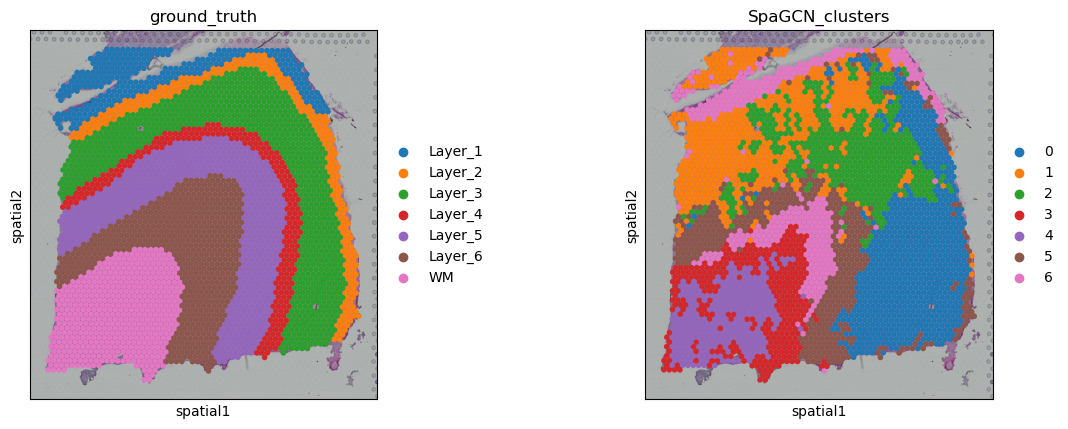

In [34]:
# plot ground-truth left and predicted cluster labels on the right
sc.pl.spatial(adata_spg,color=['ground_truth','SpaGCN_clusters'],size=1.5)

In [35]:
mut_info_10=metrics.fowlkes_mallows_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
adj_rand_10=metrics.adjusted_rand_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
adj_mut_info_10=metrics.adjusted_mutual_info_score(adata_spg.obs['SpaGCN_clusters'],histo_2['Annotations'])
print(f"FMI  (Fowlkes-Mallows Index)       = {mut_info_10:.4f}")
print(f"ARI  (Adjusted Rand Index)         = {adj_rand_10:.4f}")
print(f"AMI  (Adjusted Mutual Information) = {adj_mut_info_10:.4f}")

FMI  (Fowlkes-Mallows Index)       = 0.3556
ARI  (Adjusted Rand Index)         = 0.2301
AMI  (Adjusted Mutual Information) = 0.3888


In [36]:
ct=pd.crosstab(
    adata_spg.obs["ground_truth"],
    adata_spg.obs["SpaGCN_clusters"]
)
ct

SpaGCN_clusters,0,1,2,3,4,5,6
ground_truth,,,,,,,
Layer_1,5,107,2,0,0,12,163
Layer_2,100,68,18,0,0,50,18
Layer_3,349,274,191,0,0,17,5
Layer_4,111,66,69,0,0,6,2
Layer_5,193,102,213,0,0,138,3
Layer_6,4,24,23,111,4,263,187
WM,0,0,0,232,301,0,0


In [37]:
# Per-layer recovery
layer_recovery = pd.DataFrame(index=ct.index)

layer_recovery['Total_spots'] = ct.sum(axis=1)
layer_recovery['Best_matching_cluster'] = ct.idxmax(axis=1)
layer_recovery['Correctly_grouped_spots'] = ct.max(axis=1)

layer_recovery['Recovery_%'] = (
    100 * layer_recovery['Correctly_grouped_spots']
    / layer_recovery['Total_spots']
)

print(layer_recovery.round(2))
recovery_s10 = layer_recovery['Recovery_%']

              Total_spots  Best_matching_cluster  Correctly_grouped_spots  \
ground_truth                                                                
Layer_1               289                      6                      163   
Layer_2               254                      0                      100   
Layer_3               836                      0                      349   
Layer_4               254                      0                      111   
Layer_5               649                      2                      213   
Layer_6               616                      5                      263   
WM                    533                      4                      301   

              Recovery_%  
ground_truth              
Layer_1            56.40  
Layer_2            39.37  
Layer_3            41.75  
Layer_4            43.70  
Layer_5            32.82  
Layer_6            42.69  
WM                 56.47  


## Comparison between svalues

In [38]:
# Print a clean summary table comparing all metrics across all three s values
print("=" * 58)
print(f"{'s value':<12} {'ARI':>12} {'FMI':>12} {'AMI':>12}")
print("-" * 58)
print(f"{'s = 0':<12} {adj_rand_0:>12.4f} {mut_info_0:>12.4f} {adj_mut_info_0:>12.4f}")   # no histology
print(f"{'s = 1':<12} {adj_rand_1:>12.4f} {mut_info_1:>12.4f} {adj_mut_info_1:>12.4f}")   # mild histology
print(f"{'s = 10':<12} {adj_rand_10:>12.4f} {mut_info_10:>12.4f} {adj_mut_info_10:>12.4f}") # strong histology
print("=" * 58)

s value               ARI          FMI          AMI
----------------------------------------------------------
s = 0              0.2912       0.4063       0.4524
s = 1              0.2335       0.3594       0.3940
s = 10             0.2301       0.3556       0.3888


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


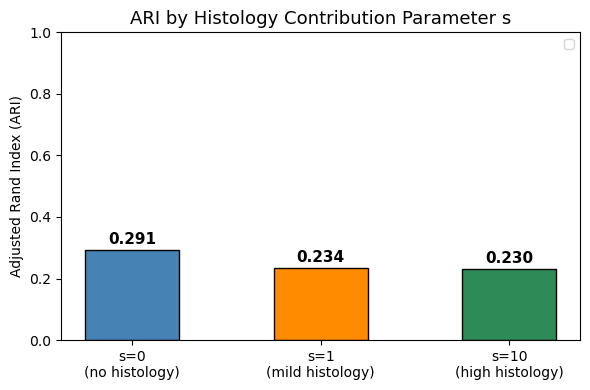

In [39]:
# ARI bar chart comparing all three s values
fig, ax = plt.subplots(figsize=(6, 4))

s_labels   = ['s=0\n(no histology)', 's=1\n(mild histology)', 's=10\n(high histology)']
ari_vals   = [adj_rand_0, adj_rand_1, adj_rand_10]        # one ARI value per run
bar_colors = ['steelblue', 'darkorange', 'seagreen']

bars = ax.bar(
    s_labels, ari_vals,
    color=bar_colors,
    edgecolor='black',
    width=0.5
)

# Annotate each bar with its exact ARI value
for bar, val in zip(bars, ari_vals):
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # horizontal centre of bar
        val + 0.01,                            # position slightly above bar top
        f"{val:.3f}",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title('ARI by Histology Contribution Parameter s', fontsize=13)
ax.set_ylabel('Adjusted Rand Index (ARI)')
ax.set_ylim(0, 1.0)           # ARI ranges from 0 (random) to 1 (perfect)
#ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', label='random baseline')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [40]:
comparison = pd.concat(
    [recovery_s0, recovery_s1, recovery_s10],
    axis=1
)

comparison.columns = ['s=0', 's=1', 's=10']

print(comparison.round(2))

                s=0    s=1   s=10
ground_truth                     
Layer_1       62.63  45.33  56.40
Layer_2       44.49  42.91  39.37
Layer_3       42.82  42.82  41.75
Layer_4       43.31  43.70  43.70
Layer_5       36.98  27.73  32.82
Layer_6       46.92  48.21  42.69
WM            74.11  57.41  56.47


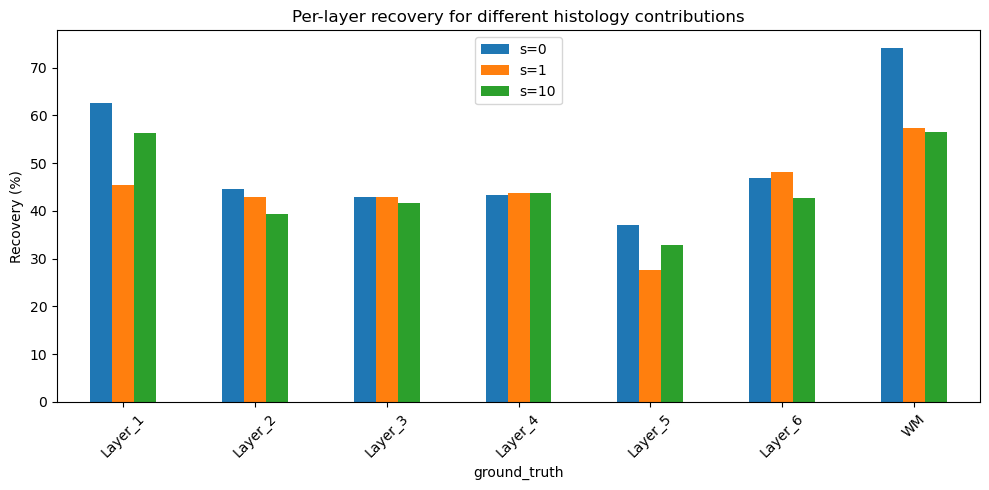

In [41]:
comparison.plot(
    kind='bar',
    figsize=(10,5)
)

plt.ylabel('Recovery (%)')
plt.title('Per-layer recovery for different histology contributions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()